In [1]:
print("My first model")

My first model


In [2]:
import pandas as pd
import matplotlib.pyplot as plt 
import seaborn as sns 



In [5]:
df = pd.read_csv('../data/cleaned_googleplaystore.csv')

In [6]:
df.head()

,Unnamed: 0,App,Category,Rating,Reviews,Size,Installs,Type,Price,Content Rating,Genres,Last Updated,Current Ver,Android Ver
0,2544,Facebook,social,4.1,78158306.0,12.0,1000000000,free,0.0,Teen,Social,"August 3, 2018",Varies with device,Varies with device
1,381,WhatsApp Messenger,communication,4.4,69119316.0,12.0,1000000000,free,0.0,Everyone,Communication,"August 3, 2018",Varies with device,Varies with device
2,2604,Instagram,social,4.5,66577446.0,12.0,1000000000,free,0.0,Teen,Social,"July 31, 2018",Varies with device,Varies with device
3,382,Messenger – Text and Video Chat for Free,communication,4.0,56646578.0,12.0,1000000000,free,0.0,Everyone,Communication,"August 1, 2018",Varies with device,Varies with device
4,1879,Clash of Clans,game,4.6,44893888.0,98.0,100000000,free,0.0,Everyone 10+,Strategy,"July 15, 2018",10.322.16,4.1 and up


## What are we trying to predict?
>### predict App Rating using number of reviews
>### input ---> reviews, Output ---> Rating

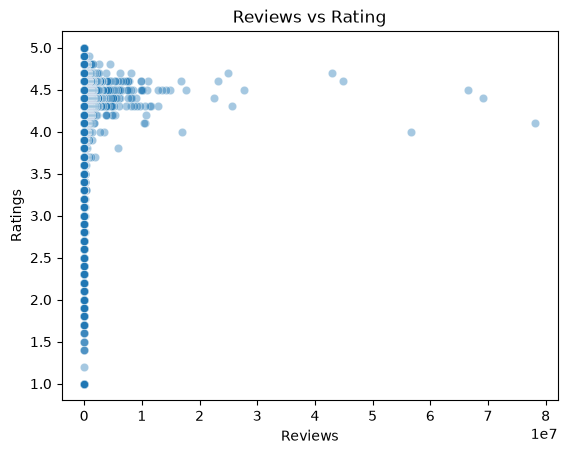

In [8]:
sns.scatterplot(data=df, x="Reviews", y="Rating", alpha=0.4)
plt.xlabel("Reviews")
plt.ylabel("Ratings")
plt.title("Reviews vs Rating")

plt.show()

In [9]:
import numpy as np
df['log_reviews'] = np.log1p(df["Reviews"])


In [10]:
model_df = df[['log_reviews', 'Rating']]

In [13]:
X = model_df[['log_reviews']]
Y = model_df['Rating']

In [15]:
model_df['log_reviews'].shape

(9659,)

In [16]:
model_df[['log_reviews']].shape

(9659, 1)

In [17]:
model_df[['log_reviews']]

,log_reviews
0,18.174247
1,18.051345
2,18.013876
3,17.852342
4,17.619812
...,...
9654,0.000000
9655,0.000000
9656,0.000000
9657,0.000000


In [ ]:
# fit() function expects the data in the following format
# input features should be in the form of num of observation X number of features


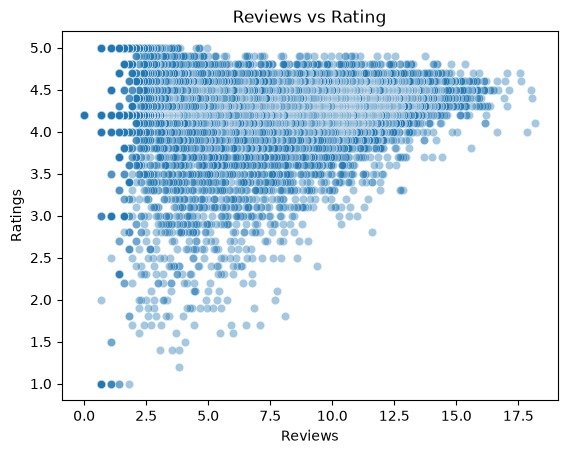

In [18]:
sns.scatterplot(data=model_df, x="log_reviews", y="Rating", alpha=0.4)
plt.xlabel("Reviews")
plt.ylabel("Ratings")
plt.title("Reviews vs Rating")

plt.show()

In [21]:
# let's split the data
from sklearn.model_selection import train_test_split
from sklearn.linear_model import LinearRegression

In [20]:
X_train, X_test, Y_train, Y_test = train_test_split(X, Y, test_size=0.2, random_state=42)

In [22]:
# Training the model

model = LinearRegression()

In [23]:
model.fit(X_train, Y_train)

,"fit_intercept fit_intercept: bool, default=TrueWhether to calculate the intercept for this model. If setto False, no intercept will be used in calculations(i.e. data is expected to be centered).",True
,"copy_X copy_X: bool, default=TrueIf True, X will be copied; else, it may be overwritten.",True
,"tol tol: float, default=1e-6The precision of the solution (`coef_`) is determined by `tol` whichspecifies the convergence criterion of the underlying solver. `tol` isset as `atol` and `btol` of :func:`scipy.sparse.linalg.lsqr` whenfitting on sparse training data. `tol` is set as `cond` of:func:`scipy.linalg.lstsq` when fitting on dense training data... versionadded:: 1.7.. versionchanged:: 1.9 Now supported on dense data, interpreted as the `cond` parameter.",1e-06
,"n_jobs n_jobs: int, default=NoneThe number of jobs to use for the computation. This will only providespeedup in case of sufficiently large problems, that is if firstly`n_targets > 1` and secondly `X` is sparse or if `positive` is setto `True`. ``None`` means 1 unless in a:obj:`joblib.parallel_backend` context. ``-1`` means using allprocessors. See :term:`Glossary <n_jobs>` for more details.",None
,"positive positive: bool, default=FalseWhen set to ``True``, forces the coefficients to be positive. Thisoption is only supported for dense arrays.For a comparison between a linear regression model with positive constraintson the regression coefficients and a linear regression without such constraints,see :ref:`sphx_glr_auto_examples_linear_model_plot_nnls.py`... versionadded:: 0.24",False
Name,Type,Value
"coef_ coef_: array of shape (n_features, ) or (n_targets, n_features)Estimated coefficients for the linear regression problem.If multiple targets are passed during the fit (y 2D), thisis a 2D array of shape (n_targets, n_features), while if onlyone target is passed, this is a 1D array of length n_features.","ndarray[float64](1,)",[0.02]
"feature_names_in_ feature_names_in_: ndarray of shape (`n_features_in_`,)Names of features seen during :term:`fit`. Defined only when `X`has feature names that are all strings... versionadded:: 1.0","ndarray[object](1,)",['log_reviews']
"intercept_ intercept_: float or array of shape (n_targets,)Independent term in the linear model. Set to 0.0 if`fit_intercept = False`.",float64,4.062
n_features_in_ n_features_in_: intNumber of features seen during :term:`fit`... versionadded:: 0.24,int,1
rank_ rank_: intRank of matrix `X`. Only available when `X` is dense.,int64,np.int64(1)


In [24]:
y_pred = model.predict(X_test)

In [25]:
y_pred

array([4.21450613, 4.0809518 , 4.22395194, ..., 4.06212716, 4.10852941,
       4.06212716], shape=(1932,))

### Evaluation

#### Mean Absolute Error
> #### $MAE = \frac{1}{n} \sum|y_i - \^y_i|$

In [26]:
from sklearn.metrics import mean_absolute_error

mae = mean_absolute_error(Y_test, y_pred)
print(f"MAE is {mae}")

MAE is 0.3377040215127806


### Mean Squared Error
> #### $MSE = \frac{1}{n} \sum(y_i - \^y_i)^2$

In [27]:
from sklearn.metrics import mean_squared_error

mse = mean_squared_error(Y_test, y_pred)

print(f"MSE is {mse}")

MSE is 0.2505065134687988


### Root Mean Squared Error
>#### $RMSE = \sqrt{MSE}$

In [28]:
rmse = np.sqrt(mse)
print(f"RMSE is {rmse}")

RMSE is 0.5005062571724741


### R^2


In [29]:
from sklearn.metrics import r2_score

r2 = r2_score(Y_test, y_pred)

print(f"the R2 score is {r2}")

the R2 score is 0.011202125873231883


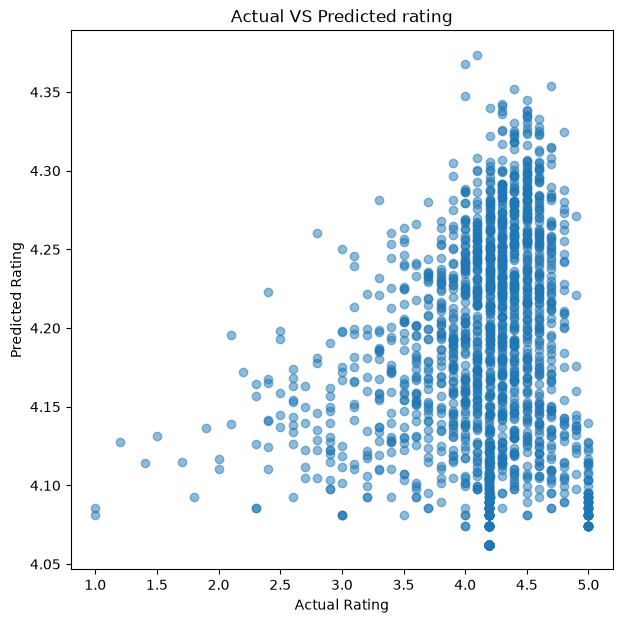

In [30]:
# plot of actual vs predicted
plt.figure(figsize=(7, 7))

plt.scatter(Y_test, y_pred, alpha=0.5)
plt.xlabel("Actual Rating")
plt.ylabel("Predicted Rating")

plt.title("Actual VS Predicted rating")
plt.show()

In [31]:
residual = Y_test - y_pred

<Axes: xlabel='Rating', ylabel='Count'>

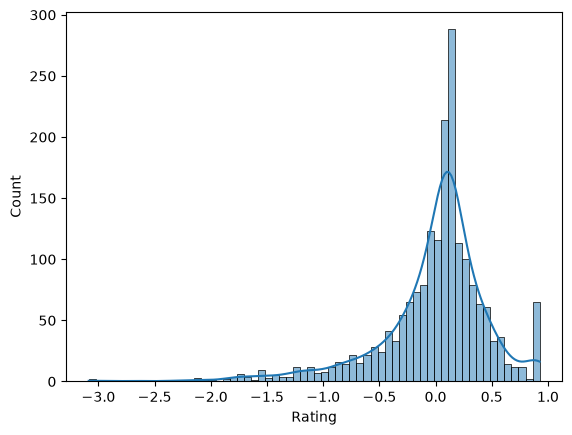

In [32]:
sns.histplot(residual, kde=True)

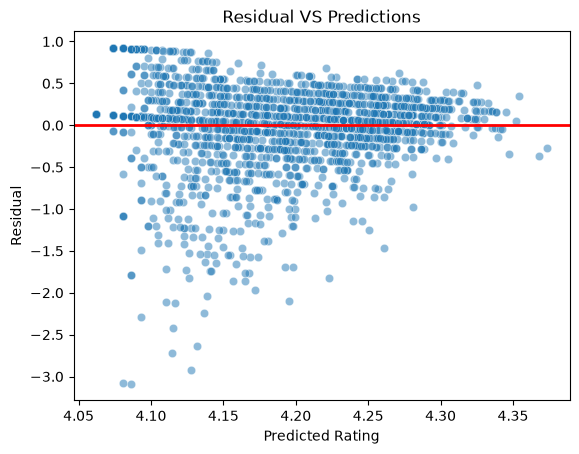

In [35]:
sns.scatterplot(x=y_pred, y=residual, alpha=0.5)

plt.axhline(0, linestyle="-", lw=2, color="red")

plt.xlabel("Predicted Rating")
plt.ylabel("Residual")
plt.title("Residual VS Predictions")
plt.show()

In [36]:
reviews = 50000
new_app = np.log1p(reviews)

model.predict([[new_app]])

/Users/amitverma/Documents/GUVI/B-202/Machine-Learning/regression/.venv/lib/python3.14/site-packages/sklearn/utils/validation.py:2827: UserWarning: X does not have valid feature names, but LinearRegression was fitted with feature names
  warnings.warn(


array([4.24752363])